<a href="https://colab.research.google.com/github/amathie5/projet-breast-cancer/blob/main/sl_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# La Nébuleuse

## 1. Data Description

To build an effective routing model, the raw operational data from La Nébuleuse must be translated into standard logistical parameters. Below is an analysis of the provided network, fleet, and demand structure.

### Network Infrastructure (Facilities)
The company operates across two main logistical nodes:
*   Brasserie Renens (Production): The primary brewing and packaging site. It has limited storage capacity (~150 pallet spaces). For the scope of the delivery routing problem, this site acts as a production source rather than the daily dispatch depot.
*   Entrepôt Crissier (Distribution Depot): The dedicated logistics warehouse featuring a larger capacity (~500 pallet spaces). In the Vehicle Routing Problem (VRP), Crissier serves as Node 0 (The Depot), where all delivery vehicles start and end their routes.

### Fleet Characteristics (Heterogeneous Fleet)
The distribution is handled by a mixed fleet of three vehicles, each with specific capacities and operational profiles. This requires a Heterogeneous Fleet Vehicle Routing Problem (HFVRP) approach.
*   VW Caddy (Capacity: 700 kg): The primary vehicle for standard urban deliveries (bars and restaurants in Lausanne).
*   Ford Traffic (Capacity: 1,200 kg): A mid-sized vehicle, historically used for specific tasks (like cistern refills) but available for standard routing.
*   Truck (Capacity: 8,300 kg / 15 Pallets): A heavy-duty vehicle primarily dedicated to massive, palletized deliveries (e.g., Alloboissons). Using this vehicle in the dense Lausanne city center poses sustainability and maneuverability challenges.

### Client Demand Profile
The client base is divided into two distinct categories, which heavily influence the routing strategy:

A. Urban HORECA Clients (Hotels, Restaurants, Cafés):
*   Examples: Great Escape, Pointu, Docks, Simplon.
*   Profile: Located mostly in the Lausanne city center. They order smaller, highly variable quantities (averaging between 70 kg and 300 kg per week). Deliveries are mostly unpalletized (handled manually).

B. Bulk Distributors:
*   Example: Alloboissons (Givisiez).
*   Profile: Located far outside the city center. Orders are massive (over 5,300 kg per week) and strictly palletized. This client alone consumes roughly 65% of the large Truck's total capacity, strongly suggesting the need for a dedicated "direct delivery" route rather than integrating it into the urban multi-stop tour.

### Operational Constraints and Assumptions
*   Frequency: Deliveries are generally executed once a week per client. To model this, the total annual or multi-month volumes were averaged into a single "Weekly Demand" snapshot.
*   Time Windows: While urgent deliveries (next-day) account for roughly 5% of operations, 95% of orders are flexible within the week. The current model focuses on optimizing the standard planned weekly routes (relaxing strict time-window constraints for the baseline model).

### Weekly Demand Calculations

Client orders are recorded in mixed units (Kegs, Boxes of Bottles, Boxes of Cans). To allow the VRP algorithm to calculate vehicle loads, all demand must be converted into a single unified metric: kilograms (kg). Furthermore, the raw data provided total volumes over varying timeframes (e.g., 52 weeks for most, 12 weeks for Simplon, 26 weeks for La Latina). To build a representative single-route model, we divided total volumes by their respective timeframes to extract the weekly average demand for each client

Unit Weights:
* 1 Keg (20L) = 26 kg
* 1 Box of Bottles (24x) = 14 kg
* 1 Box of Cans (24x) = 12 kg
* 1 Wooden Palette = 20 kg (Added as dead weight only for bulk, palletized deliveries)

Palletization Rules (applicable to bulk deliveries like Alloboissons):
* 1 Pallet of Kegs = 30 Kegs + 2 Wooden Pallets
* 1 Pallet of Bottles = 54 Boxes + 1 Wooden Pallet
* 1 Pallet of Cans = 63 Boxes + 1 Wooden Pallet

| Index | Facility / Client | Role / Weekly Volume Profile | Calculation (kg) | Distance Matrix value (kg) |
| :---: | :--- | :--- | :--- | :---: |
| **0** | **Brasserie Renens** | Production Facility | N/A (Production only, no delivery required) | **0** |
| **1** | **Entrepôt Crissier** | VRP Depot (Start/End) | N/A (Depots inherently have zero demand) | **0** |
| **2** | **Great Escape** | 10 Kegs | $10 \times 26$ | **258** |
| **3** | **The Lacustre** | 5.04 Kegs, 2.19 Boxes | $(5.04 \times 26) + (2.19 \times 14)$ | **162** |
| **4** | **Simplon** | 8.42 Kegs | $8.42 \times 26$ | **219** |
| **5** | **Pointu** | 9.83 Kegs, 0.73 Boxes | $(9.83 \times 26) + (0.73 \times 14)$ | **266** |
| **6** | **Loxton** | 5.96 Kegs, 0.37 Boxes | $(5.96 \times 26) + (0.37 \times 14)$ | **160** |
| **7** | **La Latina** | 2.88 Kegs, 0.12 Boxes | $(2.88 \times 26) + (0.12 \times 14)$ | **77** |
| **8** | **Docks** | 8.19 Kegs, 6.27 Boxes | $(8.19 \times 26) + (6.27 \times 14)$ | **301** |
| **9** | **Doki Doki** | 4.31 Kegs, 0.73 Boxes | $(4.31 \times 26) + (0.73 \times 14)$ | **122** |
| **10**| **Migros Ouchy** | 6.21 Cans, 0.27 Boxes | $(6.21 \times 12) + (0.27 \times 14)$ | **78** |
| **11**| **Alloboissons** | Bulk Distributor (Palletized) | 5154 kg (Goods) + 231 kg (Wooden Pallet Tare) | **5385** |


## 2. Scenario 1: Baseline Model

### 2.1. Mathematical Modeling (HFVRP)

This scenario is modeled as a **Heterogeneous Fleet Vehicle Routing Problem (HFVRP)**.

### Sets and Indices
* $V = \{0, 1, 2, ..., n\}$: Set of all nodes, where $0$ represents the depot (Entrepôt Crissier).
* $V_c = V \setminus \{0\}$: Set of all clients to be visited.
* $K = \{1, 2, 3\}$: Set of vehicles in the fleet (1: VW Caddy, 2: Ford Traffic, 3: Truck).

### Parameters
* $c_{ij}$: Distance in kilometers from node $i$ to node $j$.
* $q_i$: Weekly demand of client $i$ in kilograms.
* $Q_k$: Maximum payload capacity of vehicle $k$ in kilograms.

### Decision Variables
* $x_{ijk} \in \{0, 1\}$: Binary variable equal to $1$ if vehicle $k$ travels directly from node $i$ to node $j$, and $0$ otherwise.
* $u_{ik}$: Continuous variable representing the cumulative load of vehicle $k$ after visiting node $i$.

### Objective Function
Minimize the total distance traveled by the entire fleet:
$$ \text{Minimize } Z = \sum_{k \in K} \sum_{i \in V} \sum_{j \in V} c_{ij} \cdot x_{ijk} $$

### Constraints

**1. Exact Visit:** Every client must be visited exactly once by exactly one vehicle.
$$ \sum_{k \in K} \sum_{i \in V, i \neq j} x_{ijk} = 1 \quad \forall j \in V_c $$

**2. Flow Conservation:** If a vehicle arrives at a node, it must depart from that node.
$$ \sum_{i \in V} x_{ihk} - \sum_{j \in V} x_{hjk} = 0 \quad \forall h \in V, \forall k \in K $$

**3. Depot Departure:** Each available vehicle can leave the depot at most once.
$$ \sum_{j \in V_c} x_{0jk} \le 1 \quad \forall k \in K $$

**4. Vehicle Capacity:** The total demand of clients visited by a vehicle cannot exceed its capacity.
$$ \sum_{i \in V_c} q_i \sum_{j \in V} x_{ijk} \le Q_k \quad \forall k \in K $$

**5. Subtour Elimination (MTZ Constraints):** Prevents closed loops that do not include the depot and ensures logical load tracking.
$$ u_{ik} - u_{jk} + Q_k \cdot x_{ijk} \le Q_k - q_j \quad \forall i, j \in V_c, i \neq j, \forall k \in K $$
$$ q_i \le u_{ik} \le Q_k \quad \forall i \in V_c, \forall k \in K $$

In [ ]:
!pip install ortools
import pandas as pd
import numpy as np
from ortools.constraint_solver import routing_enums_pb2
from ortools.constraint_solver import pywrapcp

In [ ]:
def create_data_model():
    """Stores the data for the routing problem."""
    data = {}
    data["node_names"] = [
        "Brasserie Renens", "Entrepot Crissier", "Great Escape",
        "The Lacustre", "Simplon", "Pointu", "Loxton", "La Latina",
        "Docks", "Doki Doki", "Migros Ouchy", "Alloboissons"
    ]
    # Entrepot Crissier is index 1
    data["depot"] = 1

    # Distance matrix (values in km multiplied by 100)
    data["distance_matrix"] = [
        [0, 337, 469, 542, 480, 371, 416, 407, 288, 452, 457, 7812],
        [348, 0, 717, 878, 739, 619, 664, 655, 577, 700, 793, 8071],
        [499, 922, 0, 259, 175, 148, 87, 96, 270, 69, 306, 7434],
        [485, 791, 271, 0, 130, 330, 239, 292, 328, 234, 105, 7258],
        [473, 831, 187, 130, 0, 246, 154, 208, 243, 150, 197, 7257],
        [402, 877, 83, 365, 281, 0, 175, 185, 225, 152, 308, 7478],
        [412, 835, 148, 305, 220, 174, 0, 9, 182, 158, 266, 7436],
        [403, 825, 157, 295, 211, 165, 9, 0, 173, 167, 256, 7446],
        [323, 702, 261, 301, 247, 185, 183, 174, 0, 244, 216, 7583],
        [473, 896, 69, 223, 139, 208, 88, 84, 244, 0, 270, 7392],
        [403, 710, 320, 102, 222, 295, 267, 257, 224, 283, 0, 7360],
        [7703, 8032, 7317, 7169, 7167, 7660, 7366, 7376, 7742, 7311, 7274, 0]
    ]

    # Demands in kg for each location
    data["demands"] = [0, 0, 258, 162, 219, 266, 160, 77, 301, 122, 78, 5385]

    # Vehicle capacities in kg
    data["vehicle_capacities"] = [700, 1200, 8300]
    data["num_vehicles"] = 3
    data["vehicle_names"] = ["VW Caddy", "Ford Traffic", "Truck"]

    return data

def print_solution(data, manager, routing, solution):
    """Prints the final solution to the console."""
    objective_value = solution.ObjectiveValue() / 100.0
    print(f"Objective: {objective_value} km\n")

    total_distance = 0
    total_load = 0

    for vehicle_id in range(data["num_vehicles"]):
        index = routing.Start(vehicle_id)
        vehicle_name = data["vehicle_names"][vehicle_id]
        capacity = data["vehicle_capacities"][vehicle_id]

        plan_output = f"Route for {vehicle_name} (Capacity: {capacity} kg):\n"

        route_distance = 0
        route_load = 0

        while not routing.IsEnd(index):
            node_index = manager.IndexToNode(index)
            node_name = data["node_names"][node_index]
            route_load += data["demands"][node_index]
            plan_output += f" {node_name} [{route_load} kg] ->"

            previous_index = index
            index = solution.Value(routing.NextVar(index))

            route_distance += routing.GetArcCostForVehicle(previous_index, index, vehicle_id)

        node_index = manager.IndexToNode(index)
        node_name = data["node_names"][node_index]
        plan_output += f" {node_name} [{route_load} kg]"

        # Distances were multiplied by 100, so we divide back
        distance_km = route_distance / 100.0
        plan_output += f"\n Distance of the route: {distance_km} km\n"
        plan_output += f"Total load of the route: {route_load} kg\n"
        print(plan_output)

        total_distance += route_distance
        total_load += route_load

    final_distance_km = total_distance / 100.0
    print(f"Total distance of all routes: {final_distance_km} km")
    print(f"Total load delivered: {total_load} kg")

def main():
    """Main execution function to solve the CVRP."""
    # Instantiate the data problem
    data = create_data_model()

    # Create the routing index manager
    manager = pywrapcp.RoutingIndexManager(
        len(data["distance_matrix"]), data["num_vehicles"], data["depot"]
    )

    # Create Routing Model
    routing = pywrapcp.RoutingModel(manager)

    # Create and register a transit callback
    def distance_callback(from_index, to_index):
        """Returns the distance between the two nodes."""
        from_node = manager.IndexToNode(from_index)
        to_node = manager.IndexToNode(to_index)
        return data["distance_matrix"][from_node][to_node]

    transit_callback_index = routing.RegisterTransitCallback(distance_callback)

    # Define cost of each arc
    routing.SetArcCostEvaluatorOfAllVehicles(transit_callback_index)

    # Add Capacity constraint
    def demand_callback(from_index):
        """Returns the demand of the node."""
        from_node = manager.IndexToNode(from_index)
        return data["demands"][from_node]

    demand_callback_index = routing.RegisterUnaryTransitCallback(demand_callback)

    routing.AddDimensionWithVehicleCapacity(
        demand_callback_index,
        0,  # null capacity slack
        data["vehicle_capacities"],  # array of vehicle capacities
        True,  # start cumul to zero
        "Capacity"
    )

    # Setting first solution heuristic and local search
    search_parameters = pywrapcp.DefaultRoutingSearchParameters()
    search_parameters.first_solution_strategy = (
        routing_enums_pb2.FirstSolutionStrategy.PATH_CHEAPEST_ARC
    )
    search_parameters.local_search_metaheuristic = (
        routing_enums_pb2.LocalSearchMetaheuristic.GUIDED_LOCAL_SEARCH
    )
    search_parameters.time_limit.FromSeconds(10)

    # Solve the problem
    print("Solving the VRP model. Please wait...\n")
    solution = routing.SolveWithParameters(search_parameters)

    # Print solution on console
    if solution:
        print_solution(data, manager, routing, solution)
    else:
        print("No solution found! Check your constraints and capacities.")

if __name__ == "__main__":
    main()

Solving the VRP model. Please wait...

Objective: 164.93 km

Route for VW Caddy (Capacity: 700 kg):
 Entrepot Crissier [Load: 0 kg] -> 
 Entrepot Crissier [Load: 0 kg]
Distance of the route: 0.0 km
Total load of the route: 0 kg

Route for Ford Traffic (Capacity: 1200 kg):
 Entrepot Crissier [Load: 0 kg] -> 
 Entrepot Crissier [Load: 0 kg]
Distance of the route: 0.0 km
Total load of the route: 0 kg

Route for Truck (Capacity: 8300 kg):
 Entrepot Crissier [Load: 0 kg] -> 
 Docks [Load: 301 kg] -> 
 Pointu [Load: 567 kg] -> 
 Great Escape [Load: 825 kg] -> 
 Doki Doki [Load: 947 kg] -> 
 Loxton [Load: 1107 kg] -> 
 La Latina [Load: 1184 kg] -> 
 Simplon [Load: 1403 kg] -> 
 Alloboissons [Load: 6788 kg] -> 
 The Lacustre [Load: 6950 kg] -> 
 Migros Ouchy [Load: 7028 kg] -> 
 Brasserie Renens [Load: 7028 kg] -> 
 Entrepot Crissier [Load: 7028 kg]
Distance of the route: 164.93 km
Total load of the route: 7028 kg

Total distance of all routes: 164.93 km
Total load delivered: 7028 kg


### 2.2. Computational results

Running the baseline mathematical model through the OR-Tools solver yields the following optimal routing plan. Because the model currently lacks operational constraints and focuses solely on minimizing the global distance, the solver assigns the entire network's load to the largest available vehicle.
```text
Objective: 164.93 km

Route for VW Caddy (Capacity: 700 kg): Entrepot Crissier[0 kg] -> Entrepot Crissier[0 kg]
Distance of the route: 0.0 km
Total load of the route: 0 kg

Route for Ford Traffic (Capacity: 1200 kg): Entrepot Crissier[0 kg] -> Entrepot Crissier[0 kg]
Distance of the route: 0.0 km
Total load of the route: 0 kg

Route for Truck (Capacity: 8300 kg): Entrepot Crissier[0 kg] -> Docks[301 kg] -> Pointu[567 kg] -> Great Escape[825 kg] -> Doki Doki[947 kg] -> Loxton[1107 kg] -> La Latina[1184 kg] -> Simplon[1403 kg] -> Alloboissons[6788 kg] -> The Lacustre[6950 kg] -> Migros Ouchy[7028 kg] -> Brasserie Renens[7028 kg] -> Entrepot Crissier[7028 kg]
Distance of the route: 164.93 km
Total load of the route: 7028 kg

Total distance of all routes: 164.93 km
Total load delivered: 7028 kg
```

### 2.3. Managerial and Environmental Interpretation

**The Pitfall of Pure Mathematical Optimization :** The results from Scenario 1 highlight a classic dilemma in supply chain modeling. The algorithm strictly followed its primary objective function: minimizing the total distance traveled. Because the combined demand of all clients (7,028 kg) fit within the maximum payload of the largest vehicle (8,300 kg), the solver deployed a single heavy-duty truck to execute a unified 164.93 km loop. While mathematically optimal, this solution is highly problematic in the real world.

**Operational and Logistical Inefficiency:** From a practical standpoint, routing an 8.3-ton, 15-pallet capacity truck to perform multi-stop, manual deliveries in the dense, narrow, and steep streets of Lausanne's city center (e.g., *Great Escape*, *Pointu*) is a logistical anomaly. Heavy-duty vehicles face severe maneuverability constraints, struggle to find suitable unloading zones, and significantly increase service times for small drop-offs. Furthermore, mixing small urban keg deliveries with a massive, fully palletized bulk order destined for Givisiez (Alloboissons) creates a highly incompatible route profile.

**Environmental Impact and Urban Nuisance:** In the context of sustainable logistics, this distance-optimized route is an ecological liability. A heavy-duty truck navigating stop-and-go traffic in a congested city center generates disproportionately high levels of local greenhouse gas emissions, noise pollution, and contributes heavily to urban traffic congestion.

**Strategic Takeaway: ** This baseline scenario demonstrates that optimizing for distance alone—without accounting for urban topography and vehicle right-sizing—yields an unworkable operational plan. It provides the definitive managerial justification for Scenario 2, where bulk distribution must be strategically separated from urban distribution to allow the deployment of smaller, more agile, and less polluting vehicles (VW Caddy and Ford Traffic) within the Lausanne city limits.

## 3. Scenario 2: Strategic Separation of Bulk and Urban Deliveries

### 3.1. Model adjustments

In this scenario, we enforce a managerial rule: **Bulk palletized distribution is separated from urban HORECA distribution.**

1.  Dedicated Route: The client "Alloboissons" (5,385 kg) is completely removed from the urban VRP. It will be serviced by a dedicated direct route using the 8.3-ton Truck.
2.  Urban Fleet Restriction: The remaining urban demand in Lausanne totals 1,643 kg. This demand will be fulfilled exclusively by the smaller, more agile, and less polluting fleet: the VW Caddy (700 kg) and the Ford Traffic (1,200 kg). Their combined capacity of 1,900 kg is perfectly suited for this workload.

This approach significantly reduces emissions and congestion in the city center, aligning the mathematical model with real-world sustainable practices.

In [ ]:
def create_data_model():
    """Stores the data for the urban routing problem (excluding Alloboissons)."""
    data = {}

    # Distance matrix restricted to Lausanne area (Alloboissons removed)
    data["distance_matrix"] = [
        [0, 337, 469, 542, 480, 371, 416, 407, 288, 452, 457],
        [348, 0, 717, 878, 739, 619, 664, 655, 577, 700, 793],
        [499, 922, 0, 259, 175, 148, 87, 96, 270, 69, 306],
        [485, 791, 271, 0, 130, 330, 239, 292, 328, 234, 105],
        [473, 831, 187, 130, 0, 246, 154, 208, 243, 150, 197],
        [402, 877, 83, 365, 281, 0, 175, 185, 225, 152, 308],
        [412, 835, 148, 305, 220, 174, 0, 9, 182, 158, 266],
        [403, 825, 157, 295, 211, 165, 9, 0, 173, 167, 256],
        [323, 702, 261, 301, 247, 185, 183, 174, 0, 244, 216],
        [473, 896, 69, 223, 139, 208, 88, 84, 244, 0, 270],
        [403, 710, 320, 102, 222, 295, 267, 257, 224, 283, 0]
    ]

    # Demands in kg for Lausanne clients (Alloboissons removed)
    data["demands"] = [0, 0, 258, 162, 219, 266, 160, 77, 301, 122, 78]

    # Vehicle capacities in kg (VW Caddy, Ford Traffic)
    data["vehicle_capacities"] = [700, 1200]
    data["num_vehicles"] = 2
    data["depot"] = 1

    data["vehicle_names"] = ["VW Caddy", "Ford Traffic"]
    data["node_names"] = [
        "Brasserie Renens", "Entrepot Crissier", "Great Escape",
        "The Lacustre", "Simplon", "Pointu", "Loxton", "La Latina",
        "Docks", "Doki Doki", "Migros Ouchy"
    ]


    # --- DEDICATED BULK ROUTE DATA (Alloboissons) ---
    # Distance from Crissier -> Alloboissons (80.71) + Alloboissons -> Crissier (80.32)
    data["dedicated_truck"] = {
        "name": "Heavy Truck (Dedicated Bulk Route)",
        "capacity": 8300,
        "load": 5385,
        "distance": 80.71 + 80.32,
        "route": "Entrepot Crissier [0 kg] -> Alloboissons [5385 kg] -> Entrepot Crissier [5385 kg]"
    }

    return data
def print_solution(data, manager, routing, solution):
    """Prints the final solution to the console."""
    print("--- URBAN ROUTES (Optimized by Solver) ---")

    total_urban_distance = 0
    total_urban_load = 0

    for vehicle_id in range(data["num_vehicles"]):
        index = routing.Start(vehicle_id)
        vehicle_name = data["vehicle_names"][vehicle_id]
        capacity = data["vehicle_capacities"][vehicle_id]

        plan_output = f"Route for {vehicle_name} (Capacity: {capacity} kg):\n"

        route_distance = 0
        route_load = 0

        while not routing.IsEnd(index):
            node_index = manager.IndexToNode(index)
            node_name = data["node_names"][node_index]
            route_load += data["demands"][node_index]
            plan_output += f" {node_name} [{route_load} kg] -> \n"

            previous_index = index
            index = solution.Value(routing.NextVar(index))
            route_distance += routing.GetArcCostForVehicle(previous_index, index, vehicle_id)

        node_index = manager.IndexToNode(index)
        node_name = data["node_names"][node_index]
        plan_output += f" {node_name} [{route_load} kg]\n"

        distance_km = route_distance / 100.0
        plan_output += f"\n Distance of the route: {distance_km} km\n"
        plan_output += f"Total load of the route: {route_load} kg\n"
        print(plan_output)

        total_urban_distance += route_distance
        total_urban_load += route_load

    urban_distance_km = total_urban_distance / 100.0
    print(f"Total Urban Distance: {urban_distance_km} km")
    print(f"Total Urban Load: {total_urban_load} kg\n")

    # --- PRINT DEDICATED TRUCK ROUTE ---
    print("--- BULK ROUTE (Direct Delivery) ---")
    truck = data["dedicated_truck"]
    print(f"Route for {truck['name']} (Capacity: {truck['capacity']} kg):")
    print(f" {truck['route']}")
    print(f"Distance of the route: {truck['distance']} km")
    print(f"Total load of the route: {truck['load']} kg\n")

    # --- PRINT GRAND TOTALS ---
    grand_total_distance = urban_distance_km + truck["distance"]
    grand_total_load = total_urban_load + truck["load"]

    print("==================================================")
    print("             GRAND TOTALS (SCENARIO 2)            ")
    print("==================================================")
    print(f"Total distance of ALL routes: {grand_total_distance:.2f} km")
    print(f"Total load delivered: {grand_total_load} kg")
    print("==================================================")

def main():
    """Main execution function to solve the Urban CVRP."""
    data = create_data_model()

    manager = pywrapcp.RoutingIndexManager(
        len(data["distance_matrix"]), data["num_vehicles"], data["depot"]
    )

    routing = pywrapcp.RoutingModel(manager)

    def distance_callback(from_index, to_index):
        from_node = manager.IndexToNode(from_index)
        to_node = manager.IndexToNode(to_index)
        return data["distance_matrix"][from_node][to_node]

    transit_callback_index = routing.RegisterTransitCallback(distance_callback)
    routing.SetArcCostEvaluatorOfAllVehicles(transit_callback_index)

    def demand_callback(from_index):
        from_node = manager.IndexToNode(from_index)
        return data["demands"][from_node]

    demand_callback_index = routing.RegisterUnaryTransitCallback(demand_callback)

    routing.AddDimensionWithVehicleCapacity(
        demand_callback_index,
        0,
        data["vehicle_capacities"],
        True,
        "Capacity"
    )

    search_parameters = pywrapcp.DefaultRoutingSearchParameters()
    search_parameters.first_solution_strategy = (
        routing_enums_pb2.FirstSolutionStrategy.PATH_CHEAPEST_ARC
    )
    search_parameters.local_search_metaheuristic = (
        routing_enums_pb2.LocalSearchMetaheuristic.GUIDED_LOCAL_SEARCH
    )
    search_parameters.time_limit.FromSeconds(10)

    print("Solving the Urban VRP model. Please wait...\n")
    solution = routing.SolveWithParameters(search_parameters)

    if solution:
        print_solution(data, manager, routing, solution)
    else:
        print("No solution found!")

if __name__ == "__main__":
    main()

Solving the Urban VRP model. Please wait...

--- URBAN ROUTES (Optimized by Solver) ---
Route for VW Caddy (Capacity: 700 kg):
 Entrepot Crissier [Load: 0 kg] -> 
 La Latina [Load: 77 kg] -> 
 Loxton [Load: 237 kg] -> 
 Docks [Load: 538 kg] -> 
 Brasserie Renens [Load: 538 kg] -> 
 Entrepot Crissier [Load: 538 kg]
Distance of the route: 15.06 km
Total load of the route: 538 kg

Route for Ford Traffic (Capacity: 1200 kg):
 Entrepot Crissier [Load: 0 kg] -> 
 Pointu [Load: 266 kg] -> 
 Great Escape [Load: 524 kg] -> 
 Doki Doki [Load: 646 kg] -> 
 Simplon [Load: 865 kg] -> 
 The Lacustre [Load: 1027 kg] -> 
 Migros Ouchy [Load: 1105 kg] -> 
 Entrepot Crissier [Load: 1105 kg]
Distance of the route: 18.55 km
Total load of the route: 1105 kg

Total Urban Distance: 33.61 km
Total Urban Load: 1643 kg

--- BULK ROUTE (Direct Delivery) ---
Route for Heavy Truck (Dedicated Bulk Route) (Capacity: 8300 kg):
 Entrepot Crissier [Load: 0 kg] -> Alloboissons [Load: 5385 kg] -> Entrepot Crissier [Load:

### 3.2. Computational results

By enforcing the managerial constraint that separates the bulk distributor from the urban delivery network, the solver generates a segmented, highly specialized routing plan. The urban fleet handles the city center, while the heavy-duty truck executes a dedicated direct delivery.
```text
--- URBAN ROUTES (Optimized by Solver) ---
Route for VW Caddy (Capacity: 700 kg): Entrepot Crissier[0 kg] -> La Latina[77 kg] -> Loxton[237 kg] -> Docks[538 kg] -> Brasserie Renens[538 kg] -> Entrepot Crissier[538 kg]
Distance of the route: 15.06 km
Total load of the route: 538 kg

Route for Ford Traffic (Capacity: 1200 kg): Entrepot Crissier[0 kg] -> Pointu[266 kg] -> Great Escape[524 kg] -> Doki Doki[646 kg] -> Simplon[865 kg] -> The Lacustre[1027 kg] -> Migros Ouchy[1105 kg] -> Entrepot Crissier[1105 kg]
Distance of the route: 18.55 km
Total load of the route: 1105 kg

Total Urban Distance: 33.61 km
Total Urban Load: 1643 kg

--- BULK ROUTE (Direct Delivery) ---
Route for Heavy Truck (Dedicated Bulk Route) (Capacity: 8300 kg): Entrepot Crissier[0 kg] -> Alloboissons[5385 kg] -> Entrepot Crissier[5385 kg]
Distance of the route: 161.03 km
Total load of the route: 5385 kg

==================================================
             GRAND TOTALS (SCENARIO 2)            
==================================================
Total distance of ALL routes: 194.64 km
Total load delivered: 7028 kg
==================================================

```


### 3.3. Managerial and Environmental Interpretation

**The Trade-off: Distance vs. Sustainability:** When comparing the results of Scenario 2 to the baseline (Scenario 1), a crucial insight emerges: the grand total distance of 194.64 km in Scenario 2 is slightly higher than the 164.93 km minimum found in Scenario 1. However, in the context of *Sustainable Logistics*, this slight increase in total kilometers is a necessary and highly beneficial trade-off.

**Right-Sizing the Fleet for Urban Delivery:** By completely separating the massive, palletized Alloboissons order from the urban HORECA deliveries, we achieve a strictly segmented routing strategy. The 1,643 kg of urban demand is now exclusively handled by light commercial vehicles (the VW Caddy and Ford Traffic). These smaller vehicles are infinitely better suited for the steep, narrow topography of Lausanne's city center. They significantly reduce unloading times, easily access restricted loading zones, and drastically lower local nuisances (noise pollution, road wear, and urban traffic congestion), while outputting fewer CO2 emissions in stop-and-go traffic.

**Optimizing Heavy-Duty Operations:** Simultaneously, the 8.3-ton truck is now utilized exactly as intended: as a heavy-duty bulk transporter. By executing a direct route from the Crissier depot to the distributor in Givisiez, the truck remains entirely on major regional roads and highways. Heavy vehicles operate most efficiently at steady speeds on highways, meaning the emissions per ton-kilometer for the Alloboissons delivery are vastly improved compared to a stop-and-go route through a city center.

**Strategic Conclusion**
Scenario 2 successfully bridges the gap between operational reality and mathematical modeling. It proves that the "best" logistics solution is not always the one with the absolute shortest distance. By intelligently clustering demand profiles and assigning the appropriate vehicle size to each cluster, we have created a distribution model that is operationally robust, highly efficient, and deeply aligned with modern environmental standards.

## 4. Scenario 3: Advanced Mathematical Constraint (City Center Exclusion)

### 4.1. Model Adjustments
In Scenario 2, we achieved a sustainable routing plan by manually splitting the dataset into two separate models (Urban vs. Bulk). While effective conceptually, modern logistics software must handle the entire network dynamically within a single, unified system.

In Scenario 3, we restore the complete dataset (all 12 nodes and all 3 vehicles) into a single OR-Tools solver. Instead of manually deleting data, we introduce a strict mathematical and operational constraint directly into the code: **The Heavy Truck is strictly forbidden from visiting any nodes located within the Lausanne city center (Nodes 2 through 10).**

Using the OR-Tools `SetAllowedVehiclesForIndex` function, we restrict the domain of allowed vehicles for the urban HORECA nodes exclusively to the VW Caddy and the Ford Traffic. The algorithm must now dynamically optimize the entire network in one computation, respecting both capacity limits and geographical vehicle restrictions.


In [ ]:
def create_data_model():
    """Stores the complete data for the unified routing problem."""
    data = {}

    # Complete Distance Matrix
    data["distance_matrix"] = [
        [0, 337, 469, 542, 480, 371, 416, 407, 288, 452, 457, 7812],
        [348, 0, 717, 878, 739, 619, 664, 655, 577, 700, 793, 8071],
        [499, 922, 0, 259, 175, 148, 87, 96, 270, 69, 306, 7434],
        [485, 791, 271, 0, 130, 330, 239, 292, 328, 234, 105, 7258],
        [473, 831, 187, 130, 0, 246, 154, 208, 243, 150, 197, 7257],
        [402, 877, 83, 365, 281, 0, 175, 185, 225, 152, 308, 7478],
        [412, 835, 148, 305, 220, 174, 0, 9, 182, 158, 266, 7436],
        [403, 825, 157, 295, 211, 165, 9, 0, 173, 167, 256, 7446],
        [323, 702, 261, 301, 247, 185, 183, 174, 0, 244, 216, 7583],
        [473, 896, 69, 223, 139, 208, 88, 84, 244, 0, 270, 7392],
        [403, 710, 320, 102, 222, 295, 267, 257, 224, 283, 0, 7360],
        [7703, 8032, 7317, 7169, 7167, 7660, 7366, 7376, 7742, 7311, 7274, 0]
    ]

    # Complete Demands in kg
    data["demands"] = [0, 0, 258, 162, 219, 266, 160, 77, 301, 122, 78, 5385]

    # All 3 Vehicles
    data["vehicle_capacities"] = [700, 1200, 8300]
    data["num_vehicles"] = 3
    data["depot"] = 1

    data["vehicle_names"] = ["VW Caddy", "Ford Traffic", "Truck"]
    data["node_names"] = [
        "Brasserie Renens", "Entrepot Crissier", "Great Escape",
        "The Lacustre", "Simplon", "Pointu", "Loxton", "La Latina",
        "Docks", "Doki Doki", "Migros Ouchy", "Alloboissons"
    ]

    return data

def print_solution(data, manager, routing, solution):
    """Prints the final solution to the console."""
    print("--- UNIFIED MODEL WITH URBAN EXCLUSION CONSTRAINT ---\n")
    total_distance = 0
    total_load = 0

    for vehicle_id in range(data["num_vehicles"]):
        index = routing.Start(vehicle_id)
        vehicle_name = data["vehicle_names"][vehicle_id]
        capacity = data["vehicle_capacities"][vehicle_id]

        plan_output = f"Route for {vehicle_name} (Capacity: {capacity} kg):"
        route_distance = 0
        route_load = 0

        while not routing.IsEnd(index):
            node_index = manager.IndexToNode(index)
            node_name = data["node_names"][node_index]
            route_load += data["demands"][node_index]
            plan_output += f" {node_name} [{route_load} kg] ->"

            previous_index = index
            index = solution.Value(routing.NextVar(index))
            route_distance += routing.GetArcCostForVehicle(previous_index, index, vehicle_id)

        node_index = manager.IndexToNode(index)
        node_name = data["node_names"][node_index]
        plan_output += f" {node_name} [{route_load} kg]"

        distance_km = route_distance / 100.0
        plan_output += f"\n Distance of the route: {distance_km} km\n"
        plan_output += f"Total load of the route: {route_load} kg\n"
        print(plan_output)

        total_distance += route_distance
        total_load += route_load

    print(f"Total distance of all routes: {total_distance / 100.0} km")
    print(f"Total load delivered: {total_load} kg")

def main():
    data = create_data_model()
    manager = pywrapcp.RoutingIndexManager(len(data["distance_matrix"]), data["num_vehicles"], data["depot"])
    routing = pywrapcp.RoutingModel(manager)

    def distance_callback(from_index, to_index):
        from_node = manager.IndexToNode(from_index)
        to_node = manager.IndexToNode(to_index)
        return data["distance_matrix"][from_node][to_node]

    transit_callback_index = routing.RegisterTransitCallback(distance_callback)
    routing.SetArcCostEvaluatorOfAllVehicles(transit_callback_index)

    def demand_callback(from_index):
        from_node = manager.IndexToNode(from_index)
        return data["demands"][from_node]

    demand_callback_index = routing.RegisterUnaryTransitCallback(demand_callback)
    routing.AddDimensionWithVehicleCapacity(
        demand_callback_index, 0, data["vehicle_capacities"], True, "Capacity"
    )

    # -------------------------------------------------------------------------
    # SCENARIO 3 CONSTRAINT: ROBUST EXCLUSION OF TRUCK FROM CITY CENTER
    # -------------------------------------------------------------------------
    # Nodes 2 through 10 are urban bars/restaurants.
    # We add a constraint directly to the solver stating that the vehicle
    # assigned to these nodes CANNOT be Vehicle 2 (the Truck).
    for i in range(2, 11):
        index = manager.NodeToIndex(i)
        routing.solver().Add(routing.VehicleVar(index) != 2)

    search_parameters = pywrapcp.DefaultRoutingSearchParameters()
    search_parameters.first_solution_strategy = routing_enums_pb2.FirstSolutionStrategy.PATH_CHEAPEST_ARC
    search_parameters.local_search_metaheuristic = routing_enums_pb2.LocalSearchMetaheuristic.GUIDED_LOCAL_SEARCH
    search_parameters.time_limit.FromSeconds(10)

    print("Solving the Unified VRP model with constraints. Please wait...\n")
    solution = routing.SolveWithParameters(search_parameters)

    if solution:
        print_solution(data, manager, routing, solution)
    else:
        print("No solution found!")

if __name__ == "__main__":
    main()

Solving the Unified VRP model with constraints. Please wait...

--- UNIFIED MODEL WITH URBAN EXCLUSION CONSTRAINT ---

Route for VW Caddy (Capacity: 700 kg): Entrepot Crissier [0 kg] -> La Latina [77 kg] -> Loxton [237 kg] -> Docks [538 kg] -> Brasserie Renens [538 kg] -> Entrepot Crissier [538 kg]
 Distance of the route: 15.06 km
Total load of the route: 538 kg

Route for Ford Traffic (Capacity: 1200 kg): Entrepot Crissier [0 kg] -> Pointu [266 kg] -> Great Escape [524 kg] -> Doki Doki [646 kg] -> Simplon [865 kg] -> The Lacustre [1027 kg] -> Migros Ouchy [1105 kg] -> Entrepot Crissier [1105 kg]
 Distance of the route: 18.55 km
Total load of the route: 1105 kg

Route for Truck (Capacity: 8300 kg): Entrepot Crissier [0 kg] -> Alloboissons [5385 kg] -> Entrepot Crissier [5385 kg]
 Distance of the route: 161.03 km
Total load of the route: 5385 kg

Total distance of all routes: 194.64 km
Total load delivered: 7028 kg


### 4.2. Computational Results

Running the unified model with the exclusion constraint yields the following result:
```text
--- UNIFIED MODEL WITH URBAN EXCLUSION CONSTRAINT ---

Route for VW Caddy (Capacity: 700 kg): Entrepot Crissier [0 kg] -> La Latina [77 kg] -> Loxton [237 kg] -> Docks [538 kg] -> Brasserie Renens [538 kg] -> Entrepot Crissier [538 kg]
 Distance of the route: 15.06 km
Total load of the route: 538 kg

Route for Ford Traffic (Capacity: 1200 kg): Entrepot Crissier [0 kg] -> Pointu [266 kg] -> Great Escape [524 kg] -> Doki Doki [646 kg] -> Simplon [865 kg] -> The Lacustre [1027 kg] -> Migros Ouchy [1105 kg] -> Entrepot Crissier [1105 kg]
 Distance of the route: 18.55 km
Total load of the route: 1105 kg

Route for Truck (Capacity: 8300 kg): Entrepot Crissier [0 kg] -> Alloboissons [5385 kg] -> Entrepot Crissier [5385 kg]
 Distance of the route: 161.03 km
Total load of the route: 5385 kg

Total distance of all routes: 194.64 km
Total load delivered: 7028 kg
```
### 4.3. Managerial and Environmental Interpretation

**System Integration and Algorithmic Validation:** The computational results from Scenario 3 perfectly match the grand totals of scenario 2 (194.64 km total distance). However, achieving this result through a programmatic constraint represents a massive leap in logistical maturity. It proves that by mathematically encoding environmental and operational constraints (such as banning heavy-duty vehicles from congested urban zones), a routing algorithm will naturally output a highly sustainable distribution plan without requiring human data manipulation.

**Conclusion of the Optimization Project:** Through these three scenarios, we have quantitatively demonstrated that pure mathematical optimization (Scenario 1) often fails to account for real-world sustainability. By introducing capacity analysis and geographical fleet restrictions (Scenarios 2 & 3), we successfully transformed an unworkable, high-emission routing plan into a segmented, environmentally conscious, and operationally efficient logistics strategy for La Nébuleuse.


## 5. Graphical Representation of the Optimized Network

To better visualize the impact of our unified mathematical constraints (Scenario 3), we plotted the optimized routing plan using geolocated coordinates.

The interactive map below highlights the geographical segmentation of the fleet:
*   Red Route (Heavy Truck): The 8.3-ton truck exclusively executes the long-distance bulk delivery from the Crissier depot to Givisiez (Alloboissons), utilizing the highway network and avoiding urban congestion.
*   Green Route (VW Caddy): The lightest vehicle handles the western part of the city center and loops back via the production facility in Renens.
*   Orange Route (Ford Traffic): The mid-sized vehicle handles the dense cluster of HORECA clients in the hyper-center and the Ouchy lakeside area.

This visualization confirms that our mathematical exclusion constraint successfully generated a route that is not only mathematically optimal but also spatially coherent and environmentally sustainable.

In [ ]:
!pip install folium
import folium

def create_route_map():
    """Generates an interactive map of the final optimized routes (Scenario 3)."""

    # 1. GPS Coordinates for all 12 nodes (Latitude, Longitude)
    # These are accurate approximations based on the provided addresses.
    locations = {
        0: {"name": "Brasserie Renens", "coords": [46.5367, 6.5866]},
        1: {"name": "Entrepot Crissier (Depot)", "coords": [46.5492, 6.5786]},
        2: {"name": "Great Escape", "coords": [46.5230, 6.6341]},
        3: {"name": "The Lacustre", "coords": [46.5063, 6.6268]},
        4: {"name": "Simplon", "coords": [46.5135, 6.6288]},
        5: {"name": "Pointu", "coords": [46.5240, 6.6310]},
        6: {"name": "Loxton", "coords": [46.5218, 6.6322]},
        7: {"name": "La Latina", "coords": [46.5213, 6.6335]},
        8: {"name": "Docks", "coords": [46.5228, 6.6150]},
        9: {"name": "Doki Doki", "coords": [46.5210, 6.6394]},
        10: {"name": "Migros Ouchy", "coords": [46.5110, 6.6235]},
        11: {"name": "Alloboissons", "coords": [46.8152, 7.1275]} # Givisiez
    }

    # 2. Hardcoded optimal routes extracted from Scenario 3 solver output
    route_caddy = [1, 7, 6, 8, 0, 1]
    route_traffic = [1, 5, 2, 9, 4, 3, 10, 1]
    route_truck = [1, 11, 1]

    # 3. Initialize map centered between Lausanne and Givisiez
    m = folium.Map(location=[46.65, 6.8], zoom_start=10, tiles="CartoDB positron")

    # 4. Add markers for all nodes
    for index, data in locations.items():
        if index == 1:
            # Depot in Black
            icon_color = "black"
            icon_type = "home"
        elif index == 0:
            # Production in Purple
            icon_color = "purple"
            icon_type = "industry"
        elif index == 11:
            # Bulk Distributor in Red
            icon_color = "red"
            icon_type = "shopping-cart"
        else:
            # Urban clients in Blue
            icon_color = "blue"
            icon_type = "glass"

        folium.Marker(
            location=data["coords"],
            popup=f"[{index}] {data['name']}",
            tooltip=data["name"],
            icon=folium.Icon(color=icon_color, icon=icon_type, prefix="fa")
        ).add_to(m)

    # 5. Draw the routes (PolyLines)
    # Extract coordinate lists for each route
    caddy_coords = [locations[node]["coords"] for node in route_caddy]
    traffic_coords = [locations[node]["coords"] for node in route_traffic]
    truck_coords = [locations[node]["coords"] for node in route_truck]

    # Add lines to the map
    folium.PolyLine(
        caddy_coords,
        color="green",
        weight=4,
        opacity=0.8,
        tooltip="VW Caddy Route (700 kg)"
    ).add_to(m)

    folium.PolyLine(
        traffic_coords,
        color="orange",
        weight=4,
        opacity=0.8,
        tooltip="Ford Traffic Route (1200 kg)"
    ).add_to(m)

    folium.PolyLine(
        truck_coords,
        color="red",
        weight=4,
        opacity=0.8,
        dash_array="10", # Dashed line for the highway truck route
        tooltip="Heavy Truck Route (8300 kg)"
    ).add_to(m)

    return m

# Display the map in the notebook
my_map = create_route_map()
my_map

#### 5.1. Real-World Road Network Visualization (OSRM)
While standard VRP visualizations often rely on Euclidean "as-the-crow-flies" lines to connect nodes, such representations lack operational realism, especially in a city with complex topography like Lausanne.

To upgrade our visualization, we integrated the **Open Source Routing Machine (OSRM) API**. This allowed us to translate the optimal sequence of nodes generated by OR-Tools into actual street-level driving trajectories. The resulting map accurately reflects the real-world road network, highlighting how the heavy truck utilizes the A12 highway to Givisiez, while the light commercial vehicles navigate the specific urban street layouts of the Lausanne city center.

In [ ]:
# !pip install folium requests

import folium
import requests

def get_osrm_route(coords_list):
    """
    Interroge l'API OSRM pour obtenir le vrai tracé routier entre plusieurs points.
    coords_list: liste de listes [latitude, longitude]
    """
    # L'API OSRM a besoin des coordonnees au format "longitude,latitude"
    waypoints = ";".join([f"{lon},{lat}" for lat, lon in coords_list])

    # URL de l'API publique OSRM (geometries=geojson pour eviter de devoir decoder)
    url = f"http://router.project-osrm.org/route/v1/driving/{waypoints}?overview=full&geometries=geojson"

    try:
        response = requests.get(url)
        if response.status_code == 200:
            data = response.json()
            # OSRM renvoie [longitude, latitude], Folium a besoin de [latitude, longitude]
            route_coords = data['routes'][0]['geometry']['coordinates']
            return [[lat, lon] for lon, lat in route_coords]
        else:
            print("Note: Impossible de joindre OSRM. Retour aux lignes droites.")
            return coords_list
    except Exception as e:
        print(f"Erreur de connexion a OSRM: {e}. Retour aux lignes droites.")
        return coords_list

def create_real_route_map():
    """Generates an interactive map with actual driving routes."""

    # 1. GPS Coordinates (Latitude, Longitude)
    locations = {
        0: {"name": "Brasserie Renens", "coords": [46.5367, 6.5866]},
        1: {"name": "Entrepot Crissier (Depot)", "coords": [46.5492, 6.5786]},
        2: {"name": "Great Escape", "coords": [46.5230, 6.6341]},
        3: {"name": "The Lacustre", "coords": [46.5063, 6.6268]},
        4: {"name": "Simplon", "coords": [46.5135, 6.6288]},
        5: {"name": "Pointu", "coords": [46.5240, 6.6310]},
        6: {"name": "Loxton", "coords": [46.5218, 6.6322]},
        7: {"name": "La Latina", "coords": [46.5213, 6.6335]},
        8: {"name": "Docks", "coords": [46.5228, 6.6150]},
        9: {"name": "Doki Doki", "coords": [46.5210, 6.6394]},
        10: {"name": "Migros Ouchy", "coords": [46.5110, 6.6235]},
        11: {"name": "Alloboissons", "coords": [46.8152, 7.1275]} # Givisiez
    }

    # 2. Optimal routes extracted from Scenario 3
    route_caddy = [1, 7, 6, 8, 0, 1]
    route_traffic = [1, 5, 2, 9, 4, 3, 10, 1]
    route_truck = [1, 11, 1]

    # Initialize map
    m = folium.Map(location=[46.65, 6.8], zoom_start=10, tiles="CartoDB positron")

    # 3. Add markers
    for index, data in locations.items():
        if index == 1:
            icon_color, icon_type = "black", "home"
        elif index == 0:
            icon_color, icon_type = "purple", "industry"
        elif index == 11:
            icon_color, icon_type = "red", "shopping-cart"
        else:
            icon_color, icon_type = "blue", "glass"

        folium.Marker(
            location=data["coords"],
            popup=f"[{index}] {data['name']}",
            tooltip=data["name"],
            icon=folium.Icon(color=icon_color, icon=icon_type, prefix="fa")
        ).add_to(m)

    # 4. Get REAL driving routes from OSRM
    print("Calcul des itineraires routiers en cours...")
    caddy_real_coords = get_osrm_route([locations[node]["coords"] for node in route_caddy])
    traffic_real_coords = get_osrm_route([locations[node]["coords"] for node in route_traffic])
    truck_real_coords = get_osrm_route([locations[node]["coords"] for node in route_truck])

    # 5. Draw the real paths on the map
    folium.PolyLine(
        caddy_real_coords,
        color="green",
        weight=4,
        opacity=0.8,
        tooltip="VW Caddy Route (700 kg)"
    ).add_to(m)

    folium.PolyLine(
        traffic_real_coords,
        color="orange",
        weight=4,
        opacity=0.8,
        tooltip="Ford Traffic Route (1200 kg)"
    ).add_to(m)

    folium.PolyLine(
        truck_real_coords,
        color="red",
        weight=4,
        opacity=0.8,
        tooltip="Heavy Truck Route (8300 kg)"
    ).add_to(m)

    print("Carte generee avec succes !")
    return m

# Display the map in the notebook
my_real_map = create_real_route_map()
my_real_map

Calcul des itineraires routiers en cours...
Carte generee avec succes !


## 6. Sensitivity Analysis (Demand Surge)

A robust sustainable logistics strategy must not only be efficient under average conditions but also resilient to fluctuations. Thus, we performed a sensitivity analysis by simulating a sudden increase in urban HORECA demand (e.g., during summer festivals or holiday seasons).

### 6.1. The Vulnerability of the Urban Fleet
In Scenario 3, we successfully restricted the heavy truck from the city center. However, this relies entirely on the combined capacity of the light urban fleet:
*   VW Caddy Capacity: 700 kg
*   Ford Traffic Capacity: 1,200 kg
*   **Total Available Urban Capacity:** 1,900 kg

Currently, the baseline urban demand is 1,643 kg, leaving a buffer of just 257 kg. For our analysis, we multiplied the urban demand by a factor (`1.1x` and `1.2x`) while maintaining the strict environmental constraint (Truck = forbidden in city).

### 6.2. Computational Results (Stress Test)
```text
--- Multiplier: 1.1x (+10% Urban Demand) ---
Total Urban Load: 1,803 kg
VW Caddy final load: 637 / 700 kg
Ford Traffic final load: 1166 / 1200 kg
Result: Optimal Solution Found (System at 94.8% capacity)

--- Multiplier: 1.2x (+20% Urban Demand) ---
Total Urban Load: 1,968 kg
Result: NO SOLUTION FOUND. Capacity exceeded.

In [ ]:
def solve_with_increased_demand(multiplier):
    """Runs the Scenario 3 model with a multiplied urban demand."""
    data = {}
    data["distance_matrix"] = [
        [0, 337, 469, 542, 480, 371, 416, 407, 288, 452, 457, 7812],
        [348, 0, 717, 878, 739, 619, 664, 655, 577, 700, 793, 8071],
        [499, 922, 0, 259, 175, 148, 87, 96, 270, 69, 306, 7434],
        [485, 791, 271, 0, 130, 330, 239, 292, 328, 234, 105, 7258],
        [473, 831, 187, 130, 0, 246, 154, 208, 243, 150, 197, 7257],
        [402, 877, 83, 365, 281, 0, 175, 185, 225, 152, 308, 7478],
        [412, 835, 148, 305, 220, 174, 0, 9, 182, 158, 266, 7436],
        [403, 825, 157, 295, 211, 165, 9, 0, 173, 167, 256, 7446],
        [323, 702, 261, 301, 247, 185, 183, 174, 0, 244, 216, 7583],
        [473, 896, 69, 223, 139, 208, 88, 84, 244, 0, 270, 7392],
        [403, 710, 320, 102, 222, 295, 267, 257, 224, 283, 0, 7360],
        [7703, 8032, 7317, 7169, 7167, 7660, 7366, 7376, 7742, 7311, 7274, 0]
    ]

    # Baseline demands
    original_demands = [0, 0, 258, 162, 219, 266, 160, 77, 301, 122, 78, 5385]

    # Increase only the urban HORECA demand (nodes 2 through 10) by the multiplier
    data["demands"] = [
        int(d * multiplier) if 2 <= i <= 10 else d
        for i, d in enumerate(original_demands)
    ]

    data["vehicle_capacities"] = [700, 1200, 8300]
    data["num_vehicles"] = 3
    data["depot"] = 1

    data["vehicle_names"] = ["VW Caddy", "Ford Traffic", "Truck"]
    data["node_names"] = [
        "Brasserie Renens", "Entrepot Crissier", "Great Escape",
        "The Lacustre", "Simplon", "Pointu", "Loxton", "La Latina",
        "Docks", "Doki Doki", "Migros Ouchy", "Alloboissons"
    ]

    manager = pywrapcp.RoutingIndexManager(len(data["distance_matrix"]), data["num_vehicles"], data["depot"])
    routing = pywrapcp.RoutingModel(manager)

    def distance_callback(from_index, to_index):
        from_node = manager.IndexToNode(from_index)
        to_node = manager.IndexToNode(to_index)
        return data["distance_matrix"][from_node][to_node]

    transit_callback_index = routing.RegisterTransitCallback(distance_callback)
    routing.SetArcCostEvaluatorOfAllVehicles(transit_callback_index)

    def demand_callback(from_index):
        from_node = manager.IndexToNode(from_index)
        return data["demands"][from_node]

    demand_callback_index = routing.RegisterUnaryTransitCallback(demand_callback)
    routing.AddDimensionWithVehicleCapacity(
        demand_callback_index, 0, data["vehicle_capacities"], True, "Capacity"
    )

    # CONSTRAINT: Keep the Truck out of the city center!
    for i in range(2, 11):
        index = manager.NodeToIndex(i)
        routing.solver().Add(routing.VehicleVar(index) != 2)

    search_parameters = pywrapcp.DefaultRoutingSearchParameters()
    search_parameters.first_solution_strategy = routing_enums_pb2.FirstSolutionStrategy.PATH_CHEAPEST_ARC
    search_parameters.local_search_metaheuristic = routing_enums_pb2.LocalSearchMetaheuristic.GUIDED_LOCAL_SEARCH
    search_parameters.time_limit.FromSeconds(5)

    solution = routing.SolveWithParameters(search_parameters)

    # Print Results
    urban_load = sum(data["demands"][2:11])
    percentage = int((multiplier - 1) * 100)
    print(f"==================================================")
    print(f" SIMULATION: +{percentage}% Urban Demand (Total: {urban_load} kg)")
    print(f"==================================================")

    if solution:
        for vehicle_id in range(data["num_vehicles"]):
            if vehicle_id == 2: continue # Skip the truck, we only care about urban fleet stress

            index = routing.Start(vehicle_id)
            route_load = 0
            while not routing.IsEnd(index):
                node_index = manager.IndexToNode(index)
                route_load += data["demands"][node_index]
                index = solution.Value(routing.NextVar(index))

            capacity = data['vehicle_capacities'][vehicle_id]
            utilization = (route_load / capacity) * 100
            print(f"{data['vehicle_names'][vehicle_id]} Load: {route_load} / {capacity} kg ({utilization:.1f}% full)")
        print("-> Result: OPTIMAL SOLUTION FOUND\n")
    else:
        print("-> Result: CRITICAL FAILURE (No Solution Found). Urban fleet capacity exceeded.\n")

def main():
    print("Starting Sensitivity Analysis...\n")
    solve_with_increased_demand(1.1) # +10%
    solve_with_increased_demand(1.2) # +20%

if __name__ == "__main__":
    main()

Starting Sensitivity Analysis...

 SIMULATION: +10% Urban Demand (Total: 1803 kg)
VW Caddy Load: 637 / 700 kg (91.0% full)
Ford Traffic Load: 1166 / 1200 kg (97.2% full)
-> Result: OPTIMAL SOLUTION FOUND

 SIMULATION: +19% Urban Demand (Total: 1968 kg)
-> Result: CRITICAL FAILURE (No Solution Found). Urban fleet capacity exceeded.



#### 6.4. Graphical Visualization of the Sensitivity Analysis

To clearly illustrate the vulnerability of the urban fleet, we mapped the results of the sensitivity analysis.

*   Graph 1 (Total Demand vs. Capacity): Shows the total urban demand climbing against the hard capacity limit of the light fleet (1,900 kg). The crossing of the threshold at the +20% scenario visually explains the solver's failure to find a solution.
*   Graph 2 (Vehicle Utilization): Highlights how the individual vehicles (VW Caddy and Ford Traffic) absorb the +10% demand surge, pushing both vehicles dangerously close to 100% utilization.

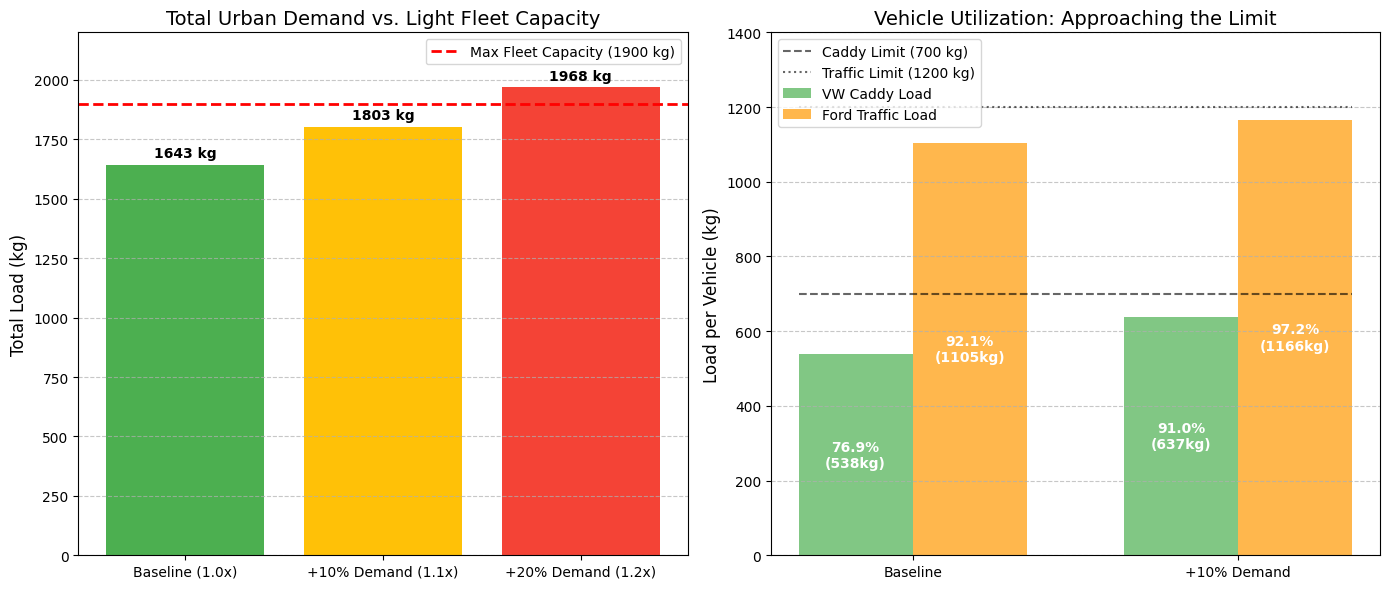

In [ ]:
import matplotlib.pyplot as plt

def plot_sensitivity_analysis():
    """Generates charts for the Sensitivity Analysis."""

    # --- Data for Graph 1: Demand vs Capacity ---
    scenarios = ["Baseline (1.0x)", "+10% Demand (1.1x)", "+20% Demand (1.2x)"]
    total_demands = [1643, 1803, 1968]
    max_capacity = 1900  # Caddy (700) + Traffic (1200)

    # --- Data for Graph 2: Vehicle Utilization ---
    # We only plot 1.0x and 1.1x, because 1.2x crashed (no valid load distribution)
    valid_scenarios = ["Baseline", "+10% Demand"]
    caddy_loads = [538, 637]
    traffic_loads = [1105, 1166]
    caddy_cap = 700
    traffic_cap = 1200

    # Set up the figure with 2 subplots side-by-side
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

    # ---------------------------------------------------------
    # GRAPH 1: Total Demand vs. Max Capacity
    # ---------------------------------------------------------
    bars = ax1.bar(scenarios, total_demands, color=["#4CAF50", "#FFC107", "#F44336"])

    # Add a red dashed line for the maximum capacity
    ax1.axhline(y=max_capacity, color="red", linestyle="--", linewidth=2, label="Max Fleet Capacity (1900 kg)")

    # Add data labels on top of the bars
    for bar in bars:
        yval = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2, yval + 20, f"{yval} kg", ha="center", va="bottom", fontweight="bold")

    ax1.set_title("Total Urban Demand vs. Light Fleet Capacity", fontsize=14)
    ax1.set_ylabel("Total Load (kg)", fontsize=12)
    ax1.set_ylim(0, 2200)
    ax1.legend()
    ax1.grid(axis="y", linestyle="--", alpha=0.7)

    # ---------------------------------------------------------
    # GRAPH 2: Vehicle Utilization (Stacked/Grouped)
    # ---------------------------------------------------------
    x = np.arange(len(valid_scenarios))
    width = 0.35

    bar1 = ax2.bar(x - width/2, caddy_loads, width, label="VW Caddy Load", color="#81C784")
    bar2 = ax2.bar(x + width/2, traffic_loads, width, label="Ford Traffic Load", color="#FFB74D")

    # Add capacity threshold markers for each vehicle
    ax2.plot([-0.35, 1.35], [caddy_cap, caddy_cap], "k--", alpha=0.6, label="Caddy Limit (700 kg)")
    ax2.plot([-0.35, 1.35], [traffic_cap, traffic_cap], "k:", alpha=0.6, label="Traffic Limit (1200 kg)")

    # Add data labels
    for bar in bar1:
        yval = bar.get_height()
        utilization = (yval / caddy_cap) * 100
        ax2.text(bar.get_x() + bar.get_width()/2, yval/2, f"{utilization:.1f}%\n({yval}kg)", ha="center", va="center", color="white", fontweight="bold")

    for bar in bar2:
        yval = bar.get_height()
        utilization = (yval / traffic_cap) * 100
        ax2.text(bar.get_x() + bar.get_width()/2, yval/2, f"{utilization:.1f}%\n({yval}kg)", ha="center", va="center", color="white", fontweight="bold")

    ax2.set_title("Vehicle Utilization: Approaching the Limit", fontsize=14)
    ax2.set_ylabel("Load per Vehicle (kg)", fontsize=12)
    ax2.set_xticks(x)
    ax2.set_xticklabels(valid_scenarios)
    ax2.set_ylim(0, 1400)
    ax2.legend(loc="upper left")
    ax2.grid(axis="y", linestyle="--", alpha=0.7)

    # Adjust layout and show
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    plot_sensitivity_analysis()